# K-Means Clustering - Analisis Nasabah Kartu Kredit

## Deskripsi Proyek
Notebook ini melakukan analisis clustering untuk mengelompokkan nasabah kartu kredit berdasarkan perilaku keuangan mereka menggunakan algoritma K-Means.

## Langkah-langkah Analisis:
1. **Deskripsi Dataset** - Analisis dan pemahaman data
2. **Data Cleaning** - Penanganan nilai hilang (NaN)
3. **Data Standardization** - Standarisasi data (mean=0, std=1)
4. **Dimensionality Reduction** - Reduksi dimensi dengan PCA dan Factor Analysis
5. **K-Means Clustering** - Pengelompokan dengan Elbow Method dan Silhouette Analysis

In [1]:
# Import libraries yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

# Define distinct colors for clusters (warna berbeda untuk setiap cluster)
distinct_colors = ['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e', '#9467bd']

## 1. Deskripsi Dataset

**Tujuan:** 
- Memahami struktur dan karakteristik dataset
- Mengetahui tipe data dan statistik deskriptif
- Mengidentifikasi nilai yang hilang (NaN)

In [2]:
# Load dataset
df = pd.read_csv('data/CC GENERAL.csv')

# Tampilkan shape dataset
print('=' * 80)
print('DESKRIPSI DATASET')
print('=' * 80)
print(f'\nShape Dataset: {df.shape[0]} baris x {df.shape[1]} kolom')

# Nama kolom dan artinya
print('\n' + '=' * 80)
print('NAMA KOLOM DAN ARTINYA')
print('=' * 80)
column_descriptions = {
    'CUST_ID': 'ID nasabah',
    'BALANCE': 'Saldo rata-rata bulanan',
    'BALANCE_FREQUENCY': 'Frekuensi saldo',
    'PURCHASES': 'Total pembelian',
    'ONEOFF_PURCHASES': 'Pembelian satu kali (bukan cicilan)',
    'INSTALLMENTS_PURCHASES': 'Pembelian dengan cicilan',
    'CASH_ADVANCE': 'Uang tunai yang ditarik dari kartu kredit',
    'PURCHASES_FREQUENCY': 'Frekuensi pembelian',
    'ONEOFF_PURCHASES_FREQUENCY': 'Frekuensi pembelian satu kali',
    'PURCHASES_INSTALLMENTS_FREQUENCY': 'Frekuensi pembelian cicilan',
    'CASH_ADVANCE_FREQUENCY': 'Frekuensi penarikan tunai',
    'CASH_ADVANCE_TRX': 'Jumlah transaksi penarikan tunai',
    'PURCHASES_TRX': 'Jumlah transaksi pembelian',
    'CREDIT_LIMIT': 'Batas kredit yang diberikan',
    'PAYMENTS': 'Pembayaran yang dilakukan',
    'MINIMUM_PAYMENTS': 'Pembayaran minimum',
    'PRC_FULL_PAYMENT': 'Persentase pembayaran penuh',
    'TENURE': 'Masa keanggotaan (bulan)'
}

for col, desc in column_descriptions.items():
    print(f'{col:35s}: {desc}')

DESKRIPSI DATASET

Shape Dataset: 8950 baris x 18 kolom

NAMA KOLOM DAN ARTINYA
CUST_ID                            : ID nasabah
BALANCE                            : Saldo rata-rata bulanan
BALANCE_FREQUENCY                  : Frekuensi saldo
PURCHASES                          : Total pembelian
ONEOFF_PURCHASES                   : Pembelian satu kali (bukan cicilan)
INSTALLMENTS_PURCHASES             : Pembelian dengan cicilan
CASH_ADVANCE                       : Uang tunai yang ditarik dari kartu kredit
PURCHASES_FREQUENCY                : Frekuensi pembelian
ONEOFF_PURCHASES_FREQUENCY         : Frekuensi pembelian satu kali
PURCHASES_INSTALLMENTS_FREQUENCY   : Frekuensi pembelian cicilan
CASH_ADVANCE_FREQUENCY             : Frekuensi penarikan tunai
CASH_ADVANCE_TRX                   : Jumlah transaksi penarikan tunai
PURCHASES_TRX                      : Jumlah transaksi pembelian
CREDIT_LIMIT                       : Batas kredit yang diberikan
PAYMENTS                           : Pem

In [3]:
# Tipe data tiap kolom
print('\n' + '=' * 80)
print('TIPE DATA TIAP KOLOM')
print('=' * 80)
print(df.dtypes)


TIPE DATA TIAP KOLOM
CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


In [4]:
# Statistik deskriptif
print('\n' + '=' * 80)
print('STATISTIK DESKRIPTIF')
print('=' * 80)
print(df.describe())


STATISTIK DESKRIPTIF
            BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
count   8950.000000        8950.000000   8950.000000       8950.000000   
mean    1564.474828           0.877271   1003.204834        592.437371   
std     2081.531879           0.236904   2136.634782       1659.887917   
min        0.000000           0.000000      0.000000          0.000000   
25%      128.281915           0.888889     39.635000          0.000000   
50%      873.385231           1.000000    361.280000         38.000000   
75%     2054.140036           1.000000   1110.130000        577.405000   
max    19043.138560           1.000000  49039.570000      40761.250000   

       INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
count             8950.000000   8950.000000          8950.000000   
mean               411.067645    978.871112             0.490351   
std                904.338115   2097.163877             0.401371   
min                  0.000000      0.00

In [5]:
# Jumlah missing values per kolom
print('\n' + '=' * 80)
print('JUMLAH MISSING VALUES PER KOLOM')
print('=' * 80)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal missing values: {df.isnull().sum().sum()}')


JUMLAH MISSING VALUES PER KOLOM
                  Missing Count  Percentage
CREDIT_LIMIT                  1    0.011173
MINIMUM_PAYMENTS            313    3.497207

Total missing values: 314


## 2. Data Analysis and Cleaning (Analisis dan Pembersihan Data)

**Tujuan:** 
- Mengecek nilai yang hilang (NaN)
- Mengisi nilai NaN dengan median (lebih tahan terhadap outlier)

In [6]:
# Fill missing values with median
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
print('Missing values after filling:', df.isnull().sum().sum())

Missing values after filling: 0


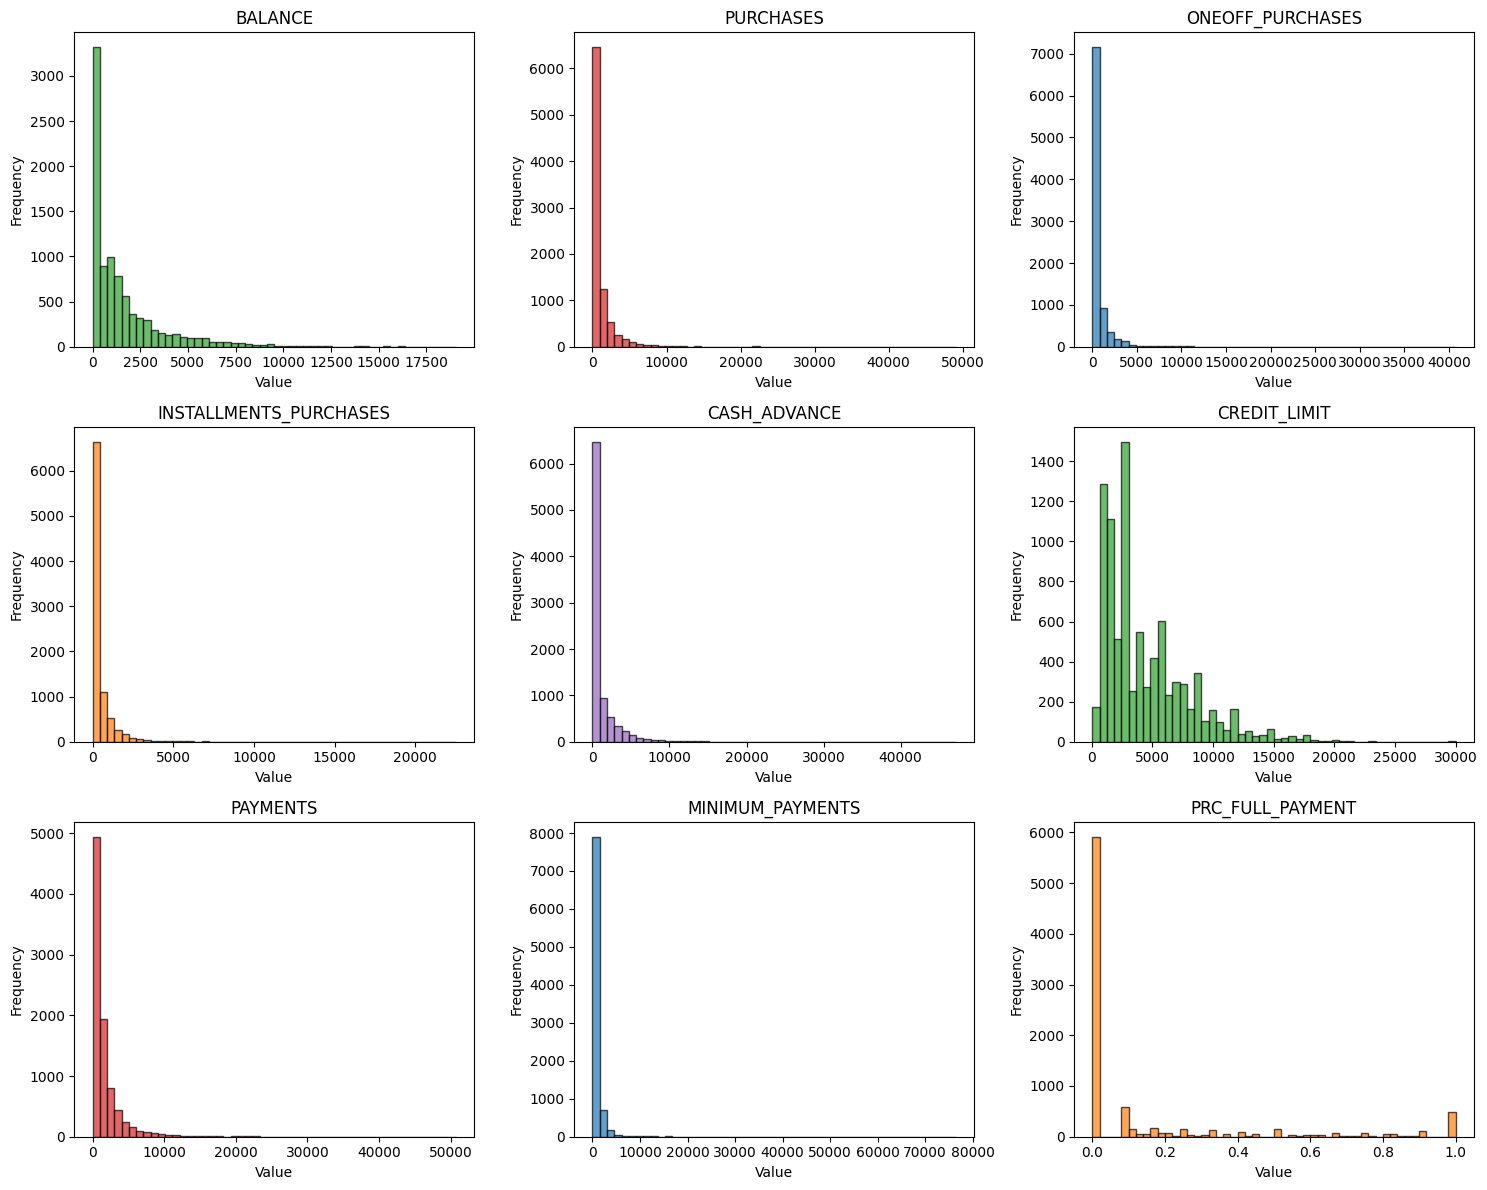

In [7]:
# Plot data distribution
feature_cols = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 
                'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color=distinct_colors[i % len(distinct_colors)])
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 3. Data Standardization (Standarisasi Data)

**Tujuan:** Mengubah semua fitur ke skala yang sama dengan mean = 0 dan standar deviasi = 1

**Mengapa harus standarisasi?**
- Fitur seperti BALANCE (0-25,000) akan mendominasi fitur seperti PRC_FULL_PAYMENT (0-1)
- K-Means menggunakan jarak Euclidean, sehingga fitur dengan skala besar akan memiliki pengaruh lebih besar
- Standarisasi memastikan semua fitur memiliki bobot yang sama

**Rumus:** `X_scaled = (X - mean) / standard_deviation`

In [8]:
# Select ALL numeric features (drop only CUST_ID)
feature_cols = [col for col in df.columns if col != 'CUST_ID']

X = df[feature_cols].values

# Standardize data (mean = 0, std = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Original data shape:', X.shape)
print('Scaled data shape:', X_scaled.shape)
print('\nMean of scaled data (should be ~0):')
print(np.mean(X_scaled, axis=0))
print('\nStandard deviation of scaled data (should be ~1):')
print(np.std(X_scaled, axis=0))

Original data shape: (8950, 17)
Scaled data shape: (8950, 17)

Mean of scaled data (should be ~0):
[-2.54048799e-17  1.58780500e-16  3.17560999e-18 -6.03365899e-17
  3.17560999e-17 -6.35121998e-18  9.32835435e-17  1.90536600e-17
  5.71609799e-17 -1.59574402e-16 -1.74658550e-17 -1.90536600e-17
  1.01619520e-16 -2.54048799e-17  1.27024400e-17 -9.52682998e-18
  2.92156119e-16]

Standard deviation of scaled data (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Dimensionality Reduction (Reduksi Dimensi)

### 4.1 PCA (Principal Component Analysis)

**Tujuan:** Mengurangi jumlah fitur dengan membuat komponen baru yang masih mempertahankan informasi penting.

**Kaiser Rule:** Memilih komponen dengan eigenvalue > 1
- Eigenvalue > 1 berarti komponen tersebut menjelaskan variansi lebih banyak daripada satu fitur asli
- Komponen dengan eigenvalue < 1 tidak lebih baik dari satu fitur asli, jadi tidak perlu dipakai

### 4.2 Factor Analysis (Analisis Faktor)

**Tujuan:** Mirip PCA, tapi mencari faktor laten (variabel tersembunyi) yang menjelaskan korelasi antar fitur.

**Kaiser Rule untuk FA:** Memilih faktor dengan eigenvalue > 1 dari correlation matrix

Eigenvalues: [4.64112269e+00 3.45372843e+00 1.49840831e+00 1.27166123e+00
 1.05832222e+00 9.75918638e-01 8.30275112e-01 7.30946222e-01
 6.45776132e-01 5.23658895e-01 4.03327742e-01 3.01506526e-01
 2.42762789e-01 2.06899443e-01 1.72172632e-01 4.54009954e-02
 1.16501572e-05]

Kaiser Rule (eigenvalue > 1): 5 components


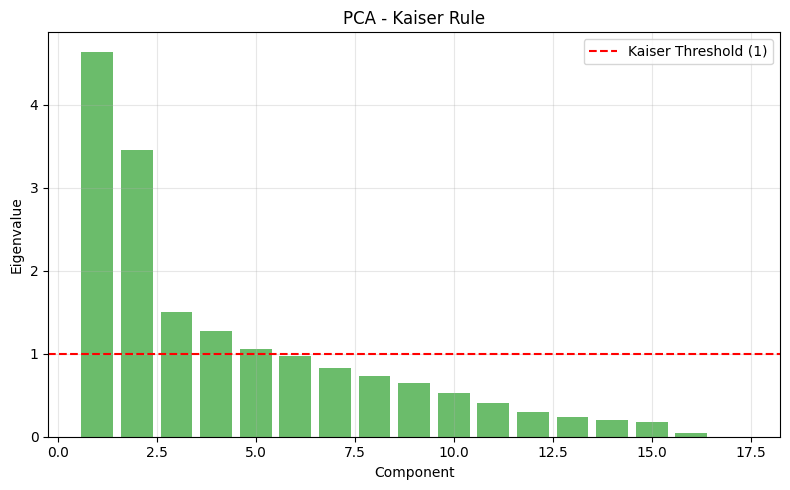

In [9]:
# PCA with Kaiser rule (eigenvalue > 1)
pca = PCA()
pca.fit(X_scaled)

eigenvalues = pca.explained_variance_
kaiser_components = np.sum(eigenvalues > 1)

print('Eigenvalues:', eigenvalues)
print(f'\nKaiser Rule (eigenvalue > 1): {kaiser_components} components')

# Plot scree plot
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(eigenvalues) + 1), eigenvalues, color=distinct_colors[0], alpha=0.7)
plt.axhline(y=1, color='red', linestyle='--', label='Kaiser Threshold (1)')
plt.xlabel('Component')
plt.ylabel('Eigenvalue')
plt.title('PCA - Kaiser Rule')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Eigenvalues from Correlation Matrix: [4.64060413e+00 3.45334253e+00 1.49824089e+00 1.27151915e+00
 1.05820397e+00 9.75809596e-01 8.30182344e-01 7.30864552e-01
 6.45703978e-01 5.23600386e-01 4.03282677e-01 3.01472838e-01
 2.42735664e-01 2.06876326e-01 1.72153395e-01 4.53959227e-02
 1.16488555e-05]

Kaiser Rule for FA (eigenvalue > 1): 5 factors


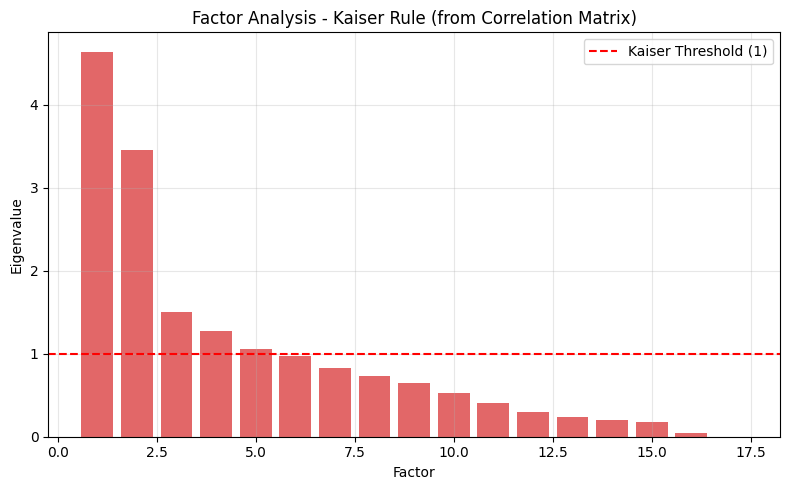

In [10]:
# Factor Analysis with Kaiser rule using correlation matrix eigenvalues
corr_matrix = np.corrcoef(X_scaled.T)
eig_vals, _ = np.linalg.eigh(corr_matrix)
eig_vals = np.sort(eig_vals)[::-1]

n_kaiser_fa = np.sum(eig_vals > 1)

print('Eigenvalues from Correlation Matrix:', eig_vals)
print(f'\nKaiser Rule for FA (eigenvalue > 1): {n_kaiser_fa} factors')

# Plot factor eigenvalues
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(eig_vals) + 1), eig_vals, color=distinct_colors[1], alpha=0.7)
plt.axhline(y=1, color='red', linestyle='--', label='Kaiser Threshold (1)')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.title('Factor Analysis - Kaiser Rule (from Correlation Matrix)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. K-Means Clustering

**Tujuan:** Mengelompokkan nasabah ke dalam segmen-segmen yang memiliki karakteristik serupa.

**Catatan:** Menggunakan hasil PCA untuk clustering (bukan X_scaled langsung)

### 5.1 Elbow Method
**Tujuan:** Mencari jumlah cluster (k) optimal dengan melihat titik "siku" pada grafik inertia.

**Inertia (SSE):** Jarak kuadrat setiap titik ke centroid cluster-nya. Semakin kecil inertia, semakin baik clustering-nya.

### 5.2 Silhouette Analysis
**Tujuan:** Mengukur seberapa baik setiap data berada dalam cluster-nya.

**Silhouette Score:** Berkisar dari -1 sampai +1
- Score mendekati +1: Cluster sangat baik
- Score mendekati 0: Cluster overlap
- Score negatif: Cluster salah assign

**Keuntungan Silhouette dibanding Elbow:** Memberikan score kuantitatif, bukan hanya visual.

In [11]:
# Apply PCA with Kaiser-selected components
n_components_pca = kaiser_components
pca_reduced = PCA(n_components=n_components_pca)
X_pca = pca_reduced.fit_transform(X_scaled)

print(f'PCA reduced data shape: {X_pca.shape}')
print(f'Total explained variance: {sum(pca_reduced.explained_variance_ratio_):.4f}')

PCA reduced data shape: (8950, 5)
Total explained variance: 0.7013


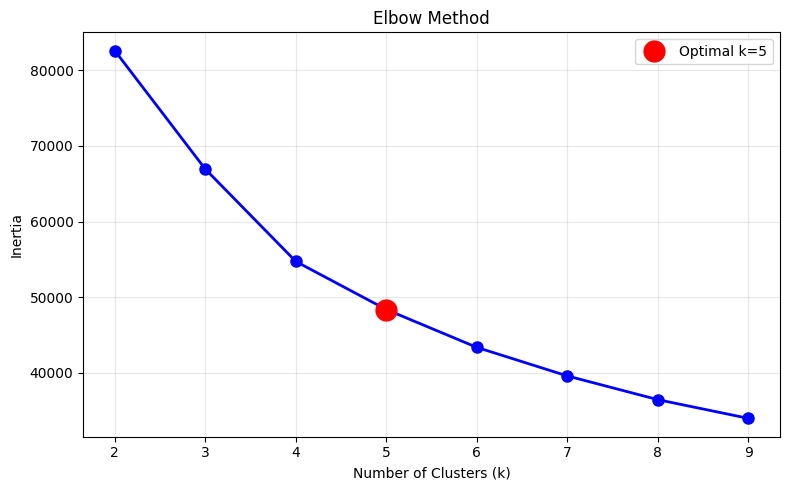

Optimal k (Elbow): 5


In [12]:
# Elbow Method with automatic optimal k detection using second derivative
k_range = range(2, 10)
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)  # Use PCA-transformed data
    inertias.append(kmeans.inertia_)

# Automatic elbow detection using second derivative
diffs = np.diff(inertias)
diffs2 = np.diff(diffs)
optimal_k_elbow = list(k_range)[np.argmax(diffs2) + 2]

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.plot(optimal_k_elbow, inertias[optimal_k_elbow-2], 'ro', markersize=15, label=f'Optimal k={optimal_k_elbow}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Optimal k (Elbow): {optimal_k_elbow}')

Silhouette Scores for each k:
------------------------------
k = 2: Silhouette Score = 0.2814
k = 3: Silhouette Score = 0.3156
k = 4: Silhouette Score = 0.2880
k = 5: Silhouette Score = 0.2847
k = 6: Silhouette Score = 0.2715
k = 7: Silhouette Score = 0.2763
k = 8: Silhouette Score = 0.2725
k = 9: Silhouette Score = 0.2784
------------------------------


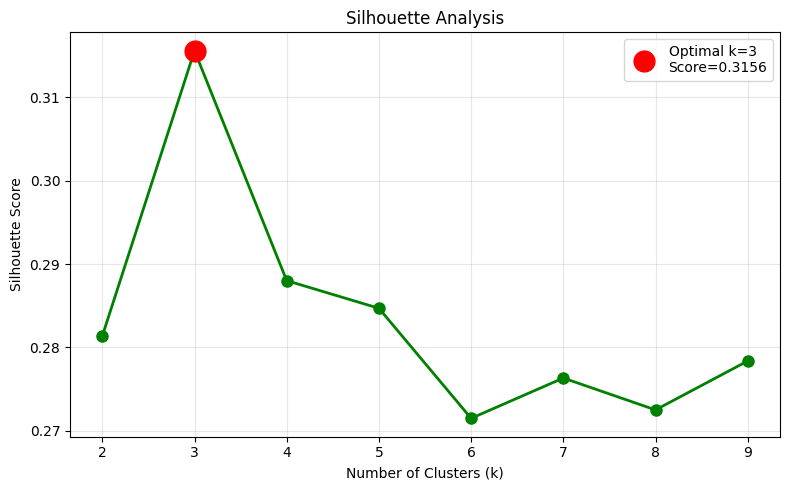


Optimal k (Silhouette): 3
Best Silhouette Score: 0.3156

COMPARISON OF OPTIMAL K VALUES
Elbow Method optimal k: 5
Silhouette Analysis optimal k: 3
--------------------------------------------------
RECOMMENDATION: Methods disagree.
  - Elbow suggests k = 5
  - Silhouette suggests k = 3 (score=0.3156)
  - Silhouette is generally more reliable (quantitative measure)

Using k = 3 for final clustering


In [13]:
# Silhouette Analysis
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)  # Use PCA-transformed data
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)

# Print all silhouette scores
print('Silhouette Scores for each k:')
print('-' * 30)
for k, score in zip(k_range, silhouette_scores):
    print(f'k = {k}: Silhouette Score = {score:.4f}')
print('-' * 30)

optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.plot(optimal_k_silhouette, best_score, 'ro', markersize=15, label=f'Optimal k={optimal_k_silhouette}\nScore={best_score:.4f}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nOptimal k (Silhouette): {optimal_k_silhouette}')
print(f'Best Silhouette Score: {best_score:.4f}')

# Compare both methods
print('\n' + '=' * 50)
print('COMPARISON OF OPTIMAL K VALUES')
print('=' * 50)
print(f'Elbow Method optimal k: {optimal_k_elbow}')
print(f'Silhouette Analysis optimal k: {optimal_k_silhouette}')
print('-' * 50)

# Recommendation
if optimal_k_elbow == optimal_k_silhouette:
    print(f'RECOMMENDATION: Both methods agree on k = {optimal_k_elbow}')
    final_k = optimal_k_elbow
else:
    print(f'RECOMMENDATION: Methods disagree.')
    print(f'  - Elbow suggests k = {optimal_k_elbow}')
    print(f'  - Silhouette suggests k = {optimal_k_silhouette} (score={best_score:.4f})')
    print(f'  - Silhouette is generally more reliable (quantitative measure)')
    final_k = optimal_k_silhouette

print(f'\nUsing k = {final_k} for final clustering')
print('=' * 50)

In [14]:
# Apply K-Means with optimal k using PCA-transformed data
optimal_k = final_k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['CLUSTER'] = kmeans_final.fit_predict(X_pca)

print('Cluster Distribution:')
print(df['CLUSTER'].value_counts().sort_index())

Cluster Distribution:
CLUSTER
0    1223
1    6129
2    1598
Name: count, dtype: int64


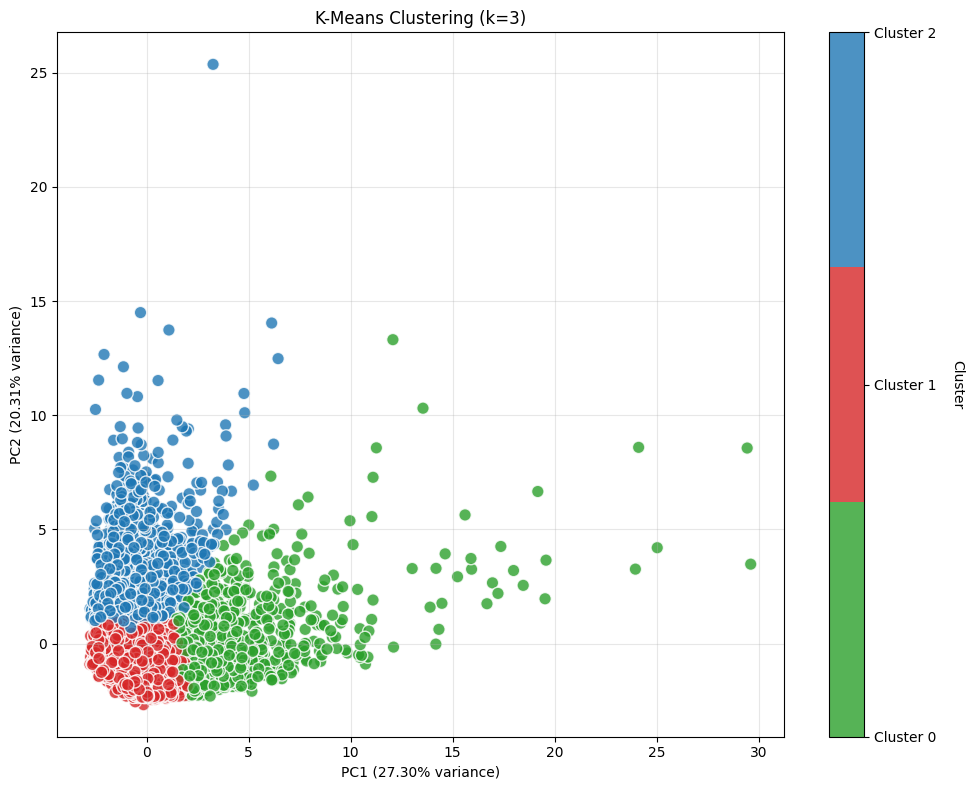

In [15]:
# PCA visualization for clusters
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=df['CLUSTER'], 
                     cmap=plt.cm.colors.ListedColormap(distinct_colors[:optimal_k]), 
                     alpha=0.8, s=80, edgecolors='white', linewidth=1)

cbar = plt.colorbar(scatter, ticks=range(optimal_k))
cbar.set_label('Cluster', rotation=270, labelpad=20)
cbar.set_ticklabels([f'Cluster {i}' for i in range(optimal_k)])

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'K-Means Clustering (k={optimal_k})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Ringkasan Cluster (Cluster Summary)

**Tujuan:** Menampilkan karakteristik masing-masing cluster yang telah terbentuk.

**Fitur yang ditampilkan:**
- BALANCE: Saldo rata-rata
- CASH_ADVANCE: Uang tunai yang ditarik
- CREDIT_LIMIT: Batas kredit
- PURCHASES: Total pembelian
- ONEOFF_PURCHASES: Pembelian satu kali
- INSTALLMENTS_PURCHASES: Pembelian cicilan
- PAYMENTS: Pembayaran
- PRC_FULL_PAYMENT: Persentase pembayaran penuh

In [16]:
# Cluster Summary
summary_cols = ['BALANCE', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PURCHASES', 'ONEOFF_PURCHASES', 
                'INSTALLMENTS_PURCHASES', 'PAYMENTS', 'PRC_FULL_PAYMENT']

cluster_summary = df.groupby('CLUSTER')[summary_cols].agg(['mean', 'std', 'count'])
cluster_summary.columns = [f'{col}_{stat}' for col, stat in cluster_summary.columns]

print('=' * 80)
print('CLUSTER SUMMARY')
print('=' * 80)

for cluster_id in range(optimal_k):
    print(f'\n### CLUSTER {cluster_id} ###')
    cluster_size = int(cluster_summary.loc[cluster_id, 'BALANCE_count'])
    print(f'Size: {cluster_size} customers ({cluster_size/len(df)*100:.1f}%)')
    print('-' * 80)
    for col in summary_cols:
        mean_val = cluster_summary.loc[cluster_id, f'{col}_mean']
        std_val = cluster_summary.loc[cluster_id, f'{col}_std']
        print(f'{col:25s}: Mean = {mean_val:12.2f}, Std = {std_val:12.2f}')
    print('-' * 80)

print('\n' + '=' * 80)

CLUSTER SUMMARY

### CLUSTER 0 ###
Size: 1223 customers (13.7%)
--------------------------------------------------------------------------------
BALANCE                  : Mean =      2246.71, Std =      2601.31
CASH_ADVANCE             : Mean =       466.19, Std =      1335.33
CREDIT_LIMIT             : Mean =      7701.35, Std =      4363.30
PURCHASES                : Mean =      4310.29, Std =      4277.10
ONEOFF_PURCHASES         : Mean =      2742.48, Std =      3641.46
INSTALLMENTS_PURCHASES   : Mean =      1568.30, Std =      1867.69
PAYMENTS                 : Mean =      4200.04, Std =      4801.36
PRC_FULL_PAYMENT         : Mean =         0.30, Std =         0.38
--------------------------------------------------------------------------------

### CLUSTER 1 ###
Size: 6129 customers (68.5%)
--------------------------------------------------------------------------------
BALANCE                  : Mean =       806.58, Std =       979.75
CASH_ADVANCE             : Mean =       32

In [17]:
# Cluster Summary Table
print('\nCluster Summary Table (Mean Values):')
display(df.groupby('CLUSTER')[summary_cols].mean().round(2))


Cluster Summary Table (Mean Values):


,BALANCE,CASH_ADVANCE,CREDIT_LIMIT,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,PAYMENTS,PRC_FULL_PAYMENT
CLUSTER,,,,,,,,
0,2246.71,466.19,7701.35,4310.29,2742.48,1568.30,4200.04,0.30
1,806.58,325.64,3304.41,506.05,254.14,252.23,908.01,0.16
2,3949.18,3876.67,6603.48,378.98,244.44,134.62,3009.88,0.03
